# Introduction to Summary Statistics - Week 3

This week's exercise helped me learn the complete data science process from data reading, cleansing, exploratory analysis to multiple visualisation methods. It also deepened my understanding of the nature of data and methods of statistical analysis, checking for concentrated trends, ranges and measures of variance.

### The Dataset 

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import colormaps

For data I chose Video Game Sales with Ratings, who has a number of categories to make it easy for me to compare statistics between subsets.

In [48]:
df = pd.read_csv(r"C:\\Users\\62704\\Documents\\GitHub\\intro-to-ds-24-25-Yinshu_Lu\\data\\Video_Games_Sales_as_at_22_Dec_2016.csv")
df

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16714,Samurai Warriors: Sanada Maru,PS3,2016.0,Action,Tecmo Koei,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16715,LMA Manager 2007,X360,2006.0,Sports,Codemasters,0.00,0.01,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16716,Haitaka no Psychedelica,PSV,2016.0,Adventure,Idea Factory,0.00,0.00,0.01,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN
16717,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.00,0.00,0.01,NaN,NaN,NaN,NaN,NaN,NaN


Since I had problems doing the statistics later, I removed the missing values here to ensure the accuracy of the subsequent statistical analyses.

In [49]:
df = df.dropna()

In [50]:
#unique labels
df["Genre"].unique()

array(['Sports', 'Racing', 'Platform', 'Misc', 'Action', 'Puzzle',
       'Shooter', 'Fighting', 'Simulation', 'Role-Playing', 'Adventure',
       'Strategy'], dtype=object)

In [51]:
#Game genre distribution
df["Genre"].value_counts()

Genre
Action          1630
Sports           943
Shooter          864
Role-Playing     712
Racing           581
Platform         403
Misc             384
Fighting         378
Simulation       297
Strategy         267
Adventure        248
Puzzle           118
Name: count, dtype: int64

Here I Check out the different game categories and their distribution.

### Samples and Populations 

In [52]:
#Using np.floor() to round all the values to nearest integer
Global_Sales = np.floor(df["Global_Sales"].values)

Text(0.5, 1.0, 'Distribution of game sales')

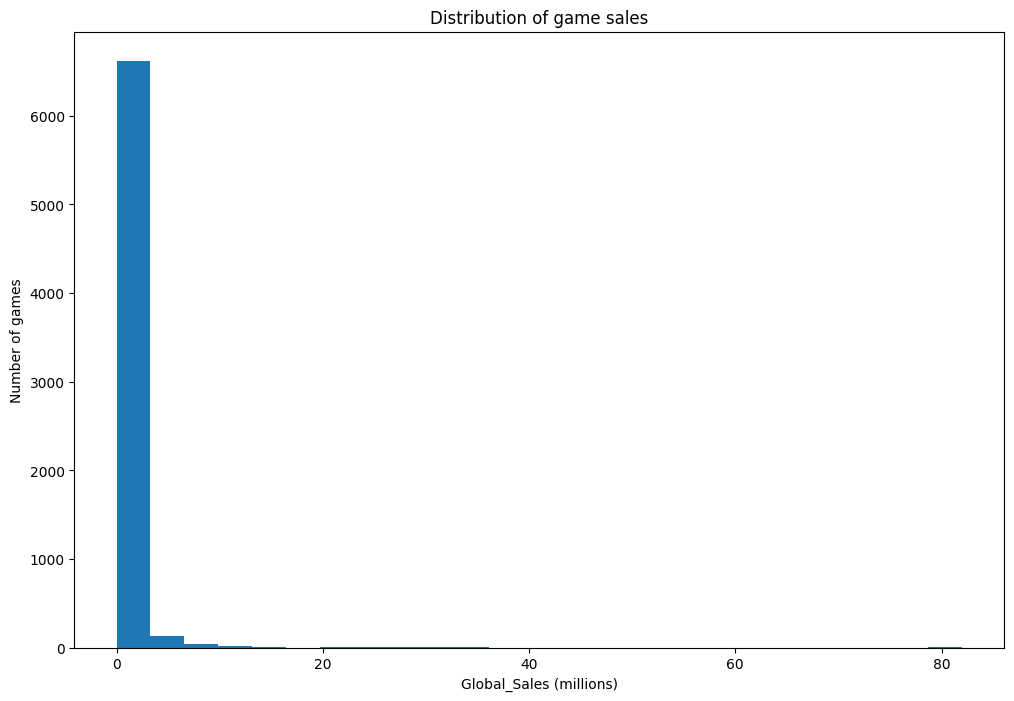

In [53]:
fig, ax = plt.subplots(figsize=(12,8)) 
number_of_bins = 25
#Plot histogram
h = ax.hist(Global_Sales, bins=number_of_bins)
ax.set_ylabel("Number of games")
ax.set_xlabel("Global_Sales (millions)")
ax.set_title("Distribution of game sales")

### Central Tendency

Here the mean, the mode and the median of the global sales are calculated in code.

In [54]:
#Mean
mean = df["Global_Sales"].mean()
print(mean)

0.7775897435897436


In [55]:
#Mode
mode = df["Global_Sales"].mode()
print(mode)

0    0.02
Name: Global_Sales, dtype: float64


In [56]:
#Median
median = df["Global_Sales"].median()
print(median)

0.29


#### Collections.Counter

The three most common sales values are calculated here using Counter.

In [57]:
# Three most common items
top_3 = Counter(Global_Sales).most_common(3)
print(top_3)

[(np.float64(0.0), 5512), (np.float64(1.0), 747), (np.float64(2.0), 242)]


### Individual Genres 

Each game category is mapped to a colour here to make it easier to distinguish between the different categories in subsequent charts. And the data is grouped by game category and the average and median sales are calculated separately for each category.

In [58]:
labels = df["Genre"].unique()
np.linspace(0,1,len(labels))

array([0.        , 0.09090909, 0.18181818, 0.27272727, 0.36363636,
       0.45454545, 0.54545455, 0.63636364, 0.72727273, 0.81818182,
       0.90909091, 1.        ])

In [59]:
#Colour map gives use a continuous range of colours
colors = colormaps['tab20']
#List comprehension gets 10 colours from the colour map between 0 and 1 (e.g. 0, 0.1, 0.2, 0.3....)
colors_list = [colors(i) for i in np.linspace(0,1,len(labels))]
colors_dict = {labels[i]:colors_list[i] for i in range(len(labels))}

In [60]:
#Group statistics by game type
grouped = df.groupby("Genre")
mean_by_genre = grouped["Global_Sales"].mean().sort_values()
median_by_genre = grouped["Global_Sales"].median()
print(mean_by_genre)

Genre
Strategy        0.260712
Adventure       0.325605
Fighting        0.661243
Puzzle          0.668644
Simulation      0.682492
Role-Playing    0.704171
Action          0.738135
Racing          0.819656
Sports          0.884252
Platform        0.937469
Shooter         0.945000
Misc            1.084010
Name: Global_Sales, dtype: float64


Text(0, 0.5, 'Sales (millions)')

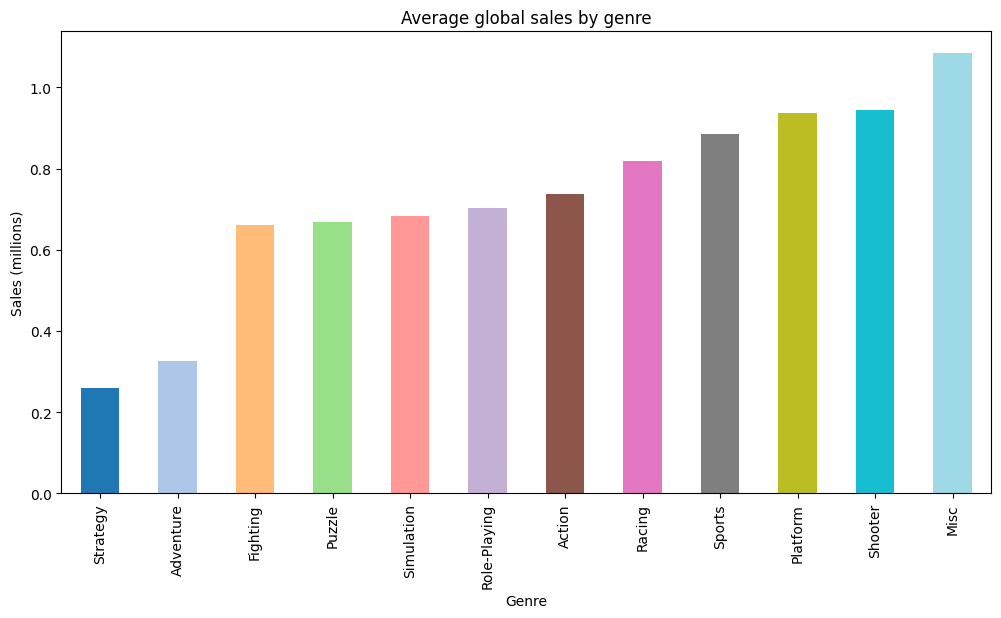

In [61]:
fig, ax = plt.subplots(figsize=(12,6))
mean_by_genre.plot(kind="bar", ax=ax, color=colors_list)
ax.set_title("Average global sales by genre")
ax.set_ylabel("Sales (millions)")

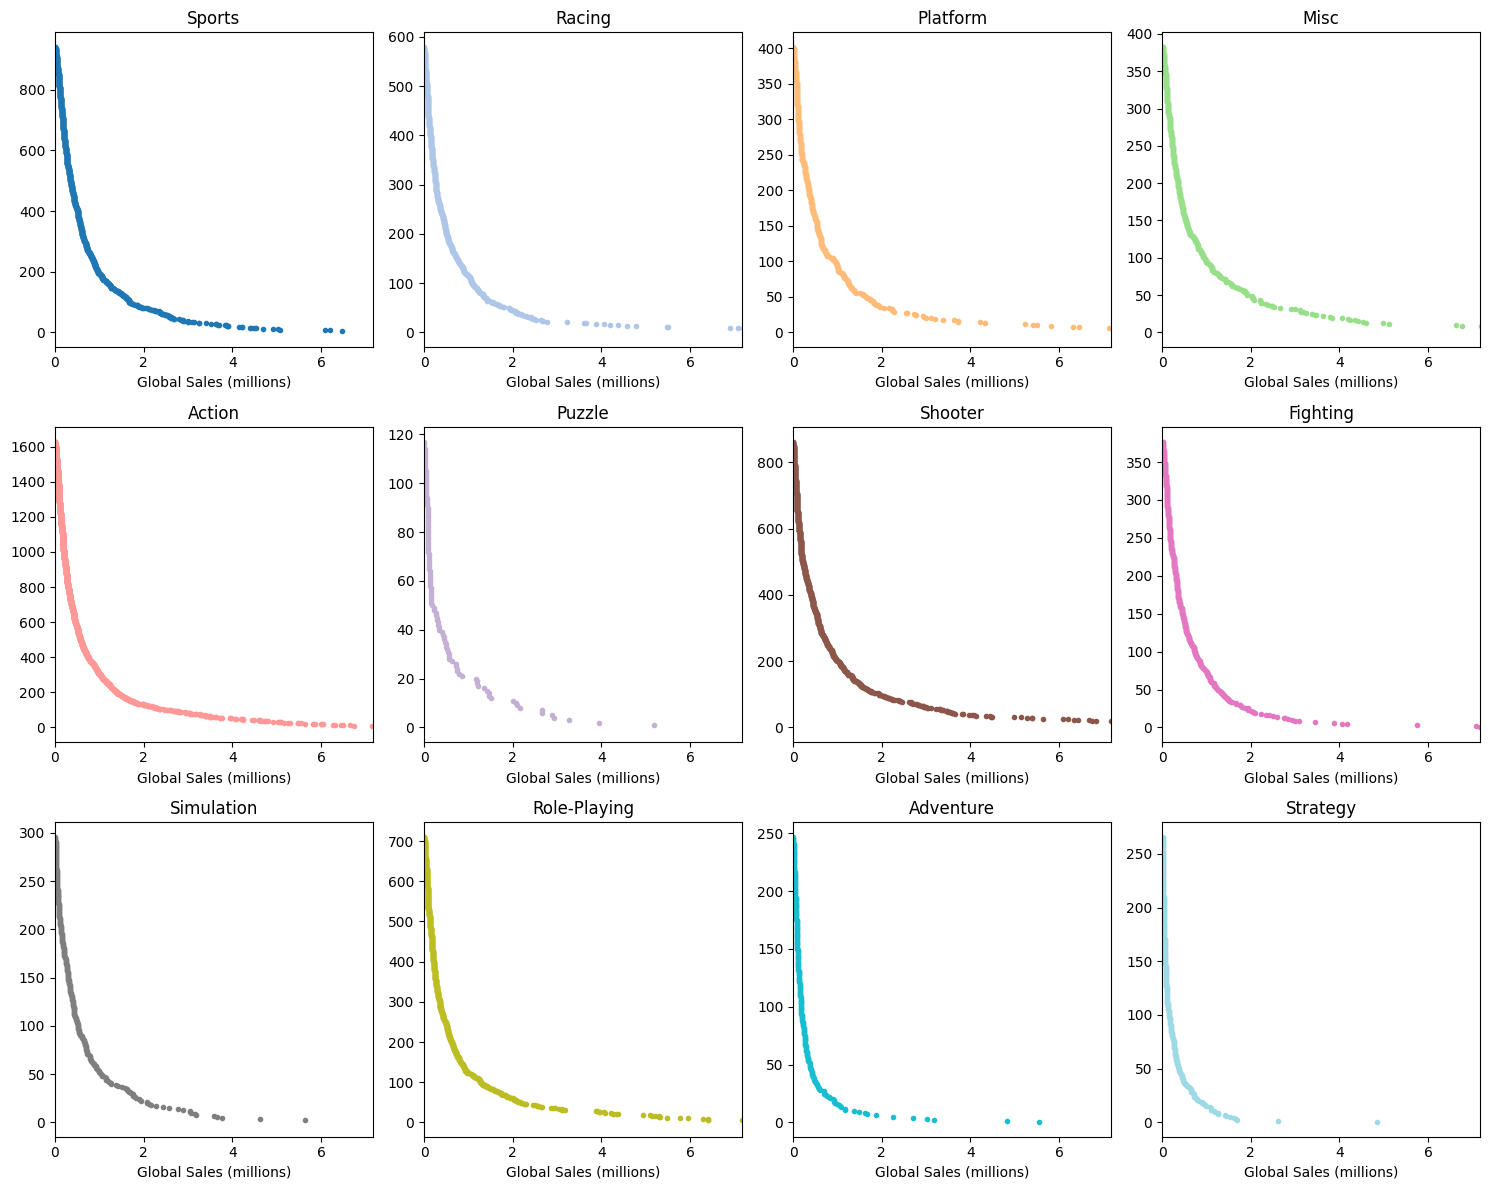

In [62]:
rows = 3
cols = 4
fig, ax = plt.subplots(rows, cols, figsize=(15, 12))

x_min = 0
x_max = df["Global_Sales"].quantile(0.99)

for i, label in enumerate(labels):
    Global_Sales = df[df["Genre"]==label]["Global_Sales"].values
    col = i%cols
    row = int(np.floor(i/cols))
    axis = ax[row,col]
    axis.plot(Global_Sales,np.arange(len(Global_Sales)), "o", color=colors_list[i], ms=3)
    axis.set_title(label)
    axis.set_xlim(x_min, x_max)
    axis.set_xlabel("Global Sales (millions)")

plt.tight_layout()
plt.show()

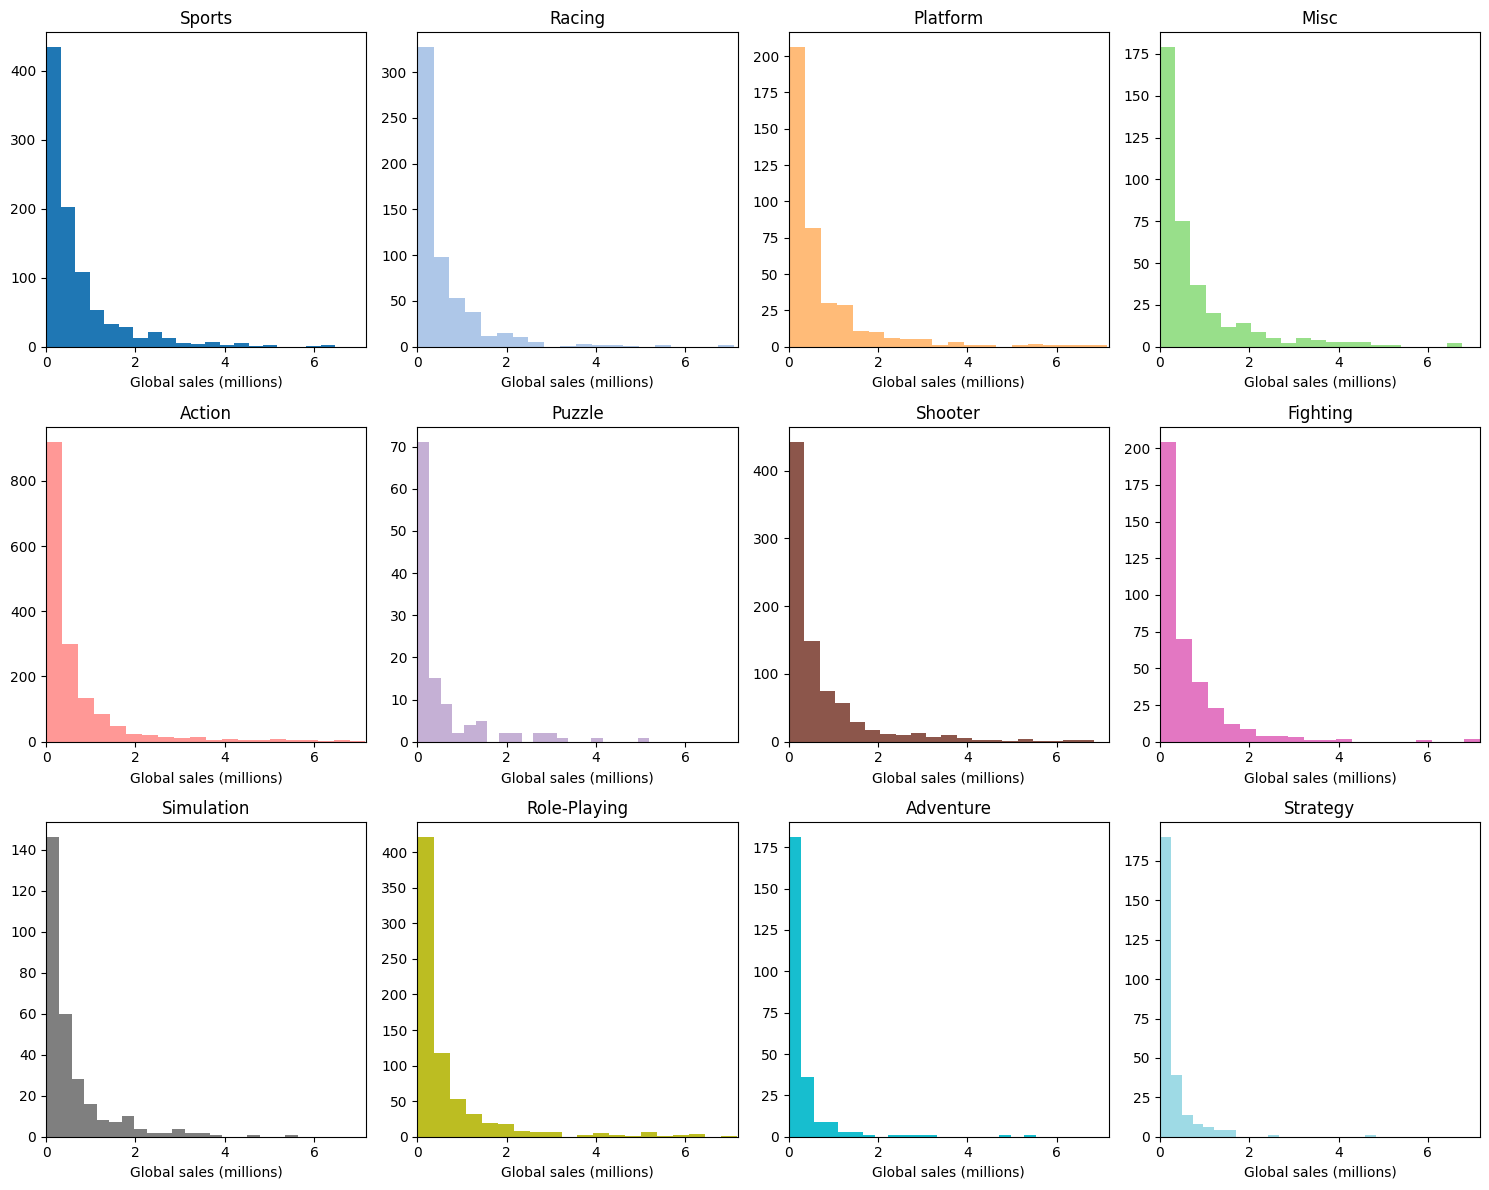

In [63]:
rows = 3
cols = 4
fig, ax = plt.subplots(rows, cols, figsize=(15,12))

x_max = df["Global_Sales"].quantile(0.99) 

for i,label in enumerate(labels):
    global_sales = df[(df["Genre"] == label) & (df["Global_Sales"] < x_max)]["Global_Sales"].values
    col = i%cols
    row = int(np.floor(i/cols))
    axis = ax[row,col]
    number_of_bins = 20
    h = axis.hist(global_sales, bins=number_of_bins,color=colors_list[i])
    axis.set_title(label)
    #Set the bounds on the x axis so all graphs are comparable
    axis.set_xlim(0, x_max)
    axis.set_xlabel("Global sales (millions)")

plt.tight_layout()
plt.show()

Through the analysis, we can see that the average sales of Shooter, Platform and Sports games are higher, which indicates that these types of games are more popular in the mainstream market and suitable for large-scale development. The Strategy type has lower average sales and may belong to a niche market.

### Range 

The use of ranges here reflects the degree of dispersion in the data for each category, which is important for understanding volatility and outliers within categories.

Genre
Strategy         4.83
Adventure        5.53
Role-Playing     9.71
Simulation      12.12
Fighting        12.83
Shooter         14.72
Puzzle          15.28
Action          21.03
Misc            28.91
Platform        29.79
Racing          35.51
Sports          82.52
dtype: float64


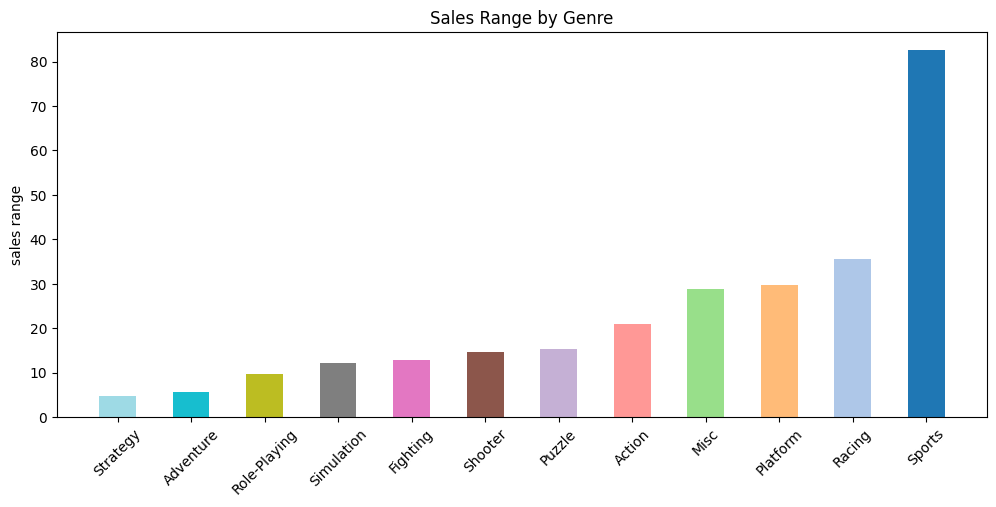

In [64]:
def sales_range(x):
    return x["Global_Sales"].max() - x["Global_Sales"].min()

#Get range from grouped items
range_sales = grouped.apply(sales_range, include_groups=False).sort_values()
print(range_sales)

#Plot
sorted_colors = [colors_dict[i] for i in range_sales.index]
fig, ax = plt.subplots(figsize=(12,5))
ax.set_ylabel("sales range")
ax.bar(range_sales.index,range_sales,0.5,color =sorted_colors)
#Characters that are too long overlap
plt.xticks(rotation=45)
plt.title("Sales Range by Genre")
plt.show()

Through the analysis we can see that Sports has the largest sales range, indicating that there may be a very small number of breakout games in these genres, but most of them are average performers. However, Strategy and Puzzle have smaller sales ranges and relatively stable market performance.

### Variance 

Here standard deviation helps us to understand the stability and anomalies of the data.

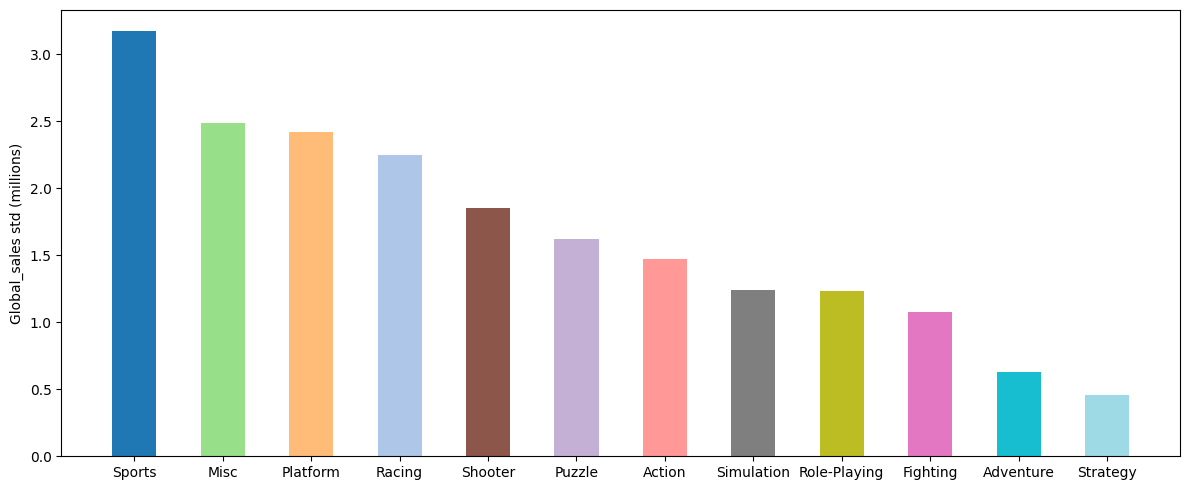

In [ ]:
#Get standard deviation from grouped items
std_dev = grouped["Global_Sales"].std().sort_values(ascending=False)

#Plot
sorted_colors = [colors_dict[i] for i in std_dev.index]
fig, ax = plt.subplots(figsize=(12,5))
ax.bar(std_dev.index,std_dev.values,0.5,color = sorted_colors)
ax.set_ylabel("Global_sales std (millions)")

plt.tight_layout()
plt.show()

Through analysis we can see that Sports has a large standard deviation, indicating that sales fluctuate significantly and may be accustomed to being on sale at a specific time. On the other hand, Strategy and Adventure have a smaller standard deviation and stable market performance, which is suitable for long-term operation.

### Z Scores 

The calculation of the Z-score helps us to find out which data points deviate from the majority of the data, which is very helpful in detecting outliers.

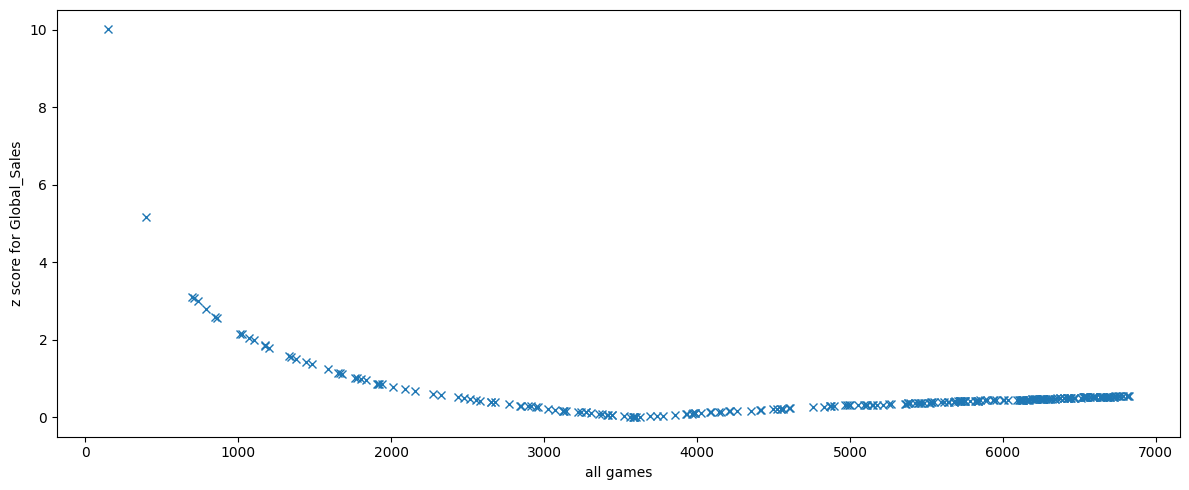

In [67]:
for genre in mean_by_genre.index:
    mean = mean_by_genre.loc[label]
    std = std_dev.loc[label]
    group = df[df["Genre"]==label]
    dist = np.abs(group["Global_Sales"]-mean)/std
    
    #select rows from group, set zscore coloumn
    df.loc[group.index,"zscore"] = dist
    
fig, ax = plt.subplots(figsize=(12,5))
y = df["zscore"].values
ax.set_ylabel("z score for Global_Sales")
ax.set_xlabel("all games")
ax.plot(y,"x")

plt.tight_layout()
plt.show()

### Reflection

The use of histograms gives a clearer picture of the frequency distribution of the data and is particularly intuitive when analysing the sales ranges within each category. From the initial reading and simple statistics, to in-depth grouping calculations, standard deviation and Z-score analysis, each step has led to a more comprehensive understanding of data distributions and statistics. I feel that these methods can also be applied in personal projects, such as analysing social media data or an individual's spending history and so on.